In [2]:
import pandas as pd

In [8]:
change_feature_cols=[  # specify the change feature columns
    "tech_investment_ratio_change",
    "nib_deposit_ratio_change",
    "service_charge_intensity_change",
    "efficiency_ratio_change",
    "nonint_income_pct_change",
    "loans_to_assets_change",
    "equity_to_assets_change",
    "deposits_to_assets_change",
    "roa_change",
    "roe_change",
    "nontrans_deposits_pct_change",
    "digital_revenue_ratio_change",
    "non_branch_revenue_pct_change",
    "loan_yield_change",
    "securities_to_assets_change",
    "expense_per_salary_dollar_change",
    "occupancy_intensity_change",
    "chargeoff_rate_change",
    "provision_intensity_change",
]

In [3]:
df_changes_optimized = pd.read_csv("data/bank_innovation_clustered_optimized.csv")

In [ ]:
from bank_innovation.migration import (
    build_bank_cluster_history,
    detect_migrations,
    compute_migration_matrix,
    compute_migration_rates_by_year,
    summarize_bank_trajectories,
    analyze_
)

history = build_bank_cluster_history(df_changes_optimized)
migrations = detect_migrations(df_changes_optimized)

print(f"\nMigration events: {len(migrations):,}")
print(f"Banks that migrated: {migrations['rssd9017'].nunique():,}")

# Migration rates over time
for tier in ['Large', 'Medium', 'Small']:
    rates = compute_migration_rates_by_year(df_changes_optimized, migrations, tier=tier)
    print(f"\n{tier} migration rates:")
    print(rates.to_string(index=False))

# Transition matrices
for tier in ['Large', 'Medium', 'Small']:
    print(f"\n{tier} transition matrix:")
    matrix = compute_migration_matrix(migrations, tier=tier)
    print(matrix.round(3).to_string())

# Bank trajectories
for tier in ['Large', 'Medium', 'Small']:
    traj = summarize_bank_trajectories(history, tier=tier)
    movers = traj[traj['n_migrations'] > 0].sort_values('n_migrations', ascending=False)
    print(f"\n{tier} — top 10 most active migrators:")
    print(movers.head(10)[['rssd9017', 'trajectory', 'n_migrations']].to_string(index=False))

/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Migration events: 5,253
Banks that migrated: 2,623

Large migration rates:
 year  total_banks  migrating_banks  migration_rate
 2013           75                0        0.000000
 2014           82               23        0.280488
 2015           96               18        0.187500
 2016           95               18        0.189474
 2017          102               16        0.156863
 2018          107               18        0.168224
 2019          116               24        0.206897
 2020          112               29        0.258929
 2021          122               50        0.409836

Medium migration rates:
 year  total_banks  migrating_banks  migration_rate
 2013          378                0        0.000000
 2014          398               47        0.118090
 2015          460               46        0.100000
 2016          478               59        0.123431
 2017          493               77        0.156187
 2018          502              105        0.209163
 2019          

In [11]:
from bank_innovation.analysis import analyze_innovation_change_clusters
from bank_innovation.clustering import assign_cluster_names

for tier in ['Large', 'Medium', 'Small']:
    tier_data = df_changes_optimized[df_changes_optimized['bank_tier'] == tier]
    clusters = sorted(c for c in tier_data['innovation_cluster'].unique() if c != -1)
    
    print(f"\n{'='*70}")
    print(f"{tier} — Cluster sizes by window end year (year_to)")
    print(f"{'='*70}")
    
    ct = pd.crosstab(
        tier_data['year_to'], 
        tier_data['innovation_cluster']
    )
    # Drop noise column if present
    if -1 in ct.columns:
        ct = ct.drop(columns=-1)
    
    print(ct.to_string())
    
    # Also show top 3 features per cluster per window period
    # Split into early (2013-2016) vs late (2017-2021)
    print(f"\n  Early (year_to <= 2016) vs Late (year_to >= 2017):")
    
    top_feats = analyze_innovation_change_clusters(
        df_changes_optimized, tier, change_feature_cols
    ).head(3)['feature'].tolist()
    
    for feat in top_feats:
        print(f"\n  {feat.replace('_change', '')}:")
        for cl in clusters:
            cl_data = tier_data[tier_data['innovation_cluster'] == cl]
            early = cl_data[cl_data['year_to'] <= 2016][feat]
            late = cl_data[cl_data['year_to'] >= 2017][feat]
            print(f"    Cluster {cl}: early={early.mean():>8.2f} (n={len(early):>3})  "
                  f"late={late.mean():>8.2f} (n={len(late):>3})")


Large — Cluster sizes by window end year (year_to)
innovation_cluster  0   1    2   3
year_to                           
2013                3   5   59   2
2014                3   2   70   0
2015                1   3   83   0
2016                1   0   93   0
2017                2   0   95   0
2018                5   0  101   0
2019                6   0  106   0
2020                3   4   87   6
2021                0  23   69  27

  Early (year_to <= 2016) vs Late (year_to >= 2017):

  nontrans_deposits_pct:
    Cluster 0: early=   -1.29 (n=  8)  late=    1.09 (n= 16)
    Cluster 1: early=    4.45 (n= 10)  late=    9.76 (n= 27)
    Cluster 2: early=    1.57 (n=305)  late=    0.84 (n=458)
    Cluster 3: early=   36.56 (n=  2)  late=   39.10 (n= 33)

  digital_revenue_ratio:
    Cluster 0: early= -149.81 (n=  8)  late= -116.67 (n= 16)
    Cluster 1: early=   -1.88 (n= 10)  late=    6.32 (n= 27)
    Cluster 2: early=   -3.07 (n=305)  late=   -1.05 (n=458)
    Cluster 3: early=    0.48 

In [12]:
# Reorder clusters and apply names
reorder_map = {
    'Large': {3: 0, 0: 1, 2: 2, 1: 3},
    'Medium': {0: 0, 2: 1, 4: 2, 1: 3, 3: 4},
    'Small': {3: 0, 0: 1, 1: 2, 2: 3},
}

for tier, mapping in reorder_map.items():
    mask = (df_changes_optimized['bank_tier'] == tier) & (df_changes_optimized['innovation_cluster'] != -1)
    df_changes_optimized.loc[mask, 'innovation_cluster'] = (
        df_changes_optimized.loc[mask, 'innovation_cluster'].map(mapping)
    )

cluster_names = {
    'Large': {
        -1: 'Noise',
        0: 'Branch Consolidators',
        1: 'Deposit Gatherers',
        2: 'Steady Operators',
        3: 'Digital Retreaters',
    },
    'Medium': {
        -1: 'Noise',
        0: 'Branch Expanders',
        1: 'Deposit Restructurers',
        2: 'Deposit Transformers',
        3: 'Steady Operators',
        4: 'Relationship Builders',
    },
    'Small': {
        -1: 'Noise',
        0: 'Rapid Capitalizers',
        1: 'Restructurers',
        2: 'Steady Operators',
        3: 'Stressed Performers',
        
    },
}

df_changes_optimized, _ = assign_cluster_names(df_changes_optimized, cluster_names)

# Verify
for tier in ['Large', 'Medium', 'Small']:
    print(f"\n{tier}:")
    tier_data = df_changes_optimized[df_changes_optimized['bank_tier'] == tier]
    print(tier_data.groupby(['innovation_cluster', 'cluster_name']).size().to_string())


Large:
innovation_cluster  cluster_name        
-1                  Noise                    48
 0                  Branch Consolidators     35
 1                  Deposit Gatherers        24
 2                  Steady Operators        763
 3                  Digital Retreaters       37

Medium:
innovation_cluster  cluster_name         
-1                  Noise                      77
 0                  Branch Expanders          250
 1                  Deposit Restructurers      54
 2                  Deposit Transformers       46
 3                  Steady Operators          125
 4                  Relationship Builders    3810

Small:
innovation_cluster  cluster_name       
-1                  Noise                   2707
 0                  Rapid Capitalizers     33577
 1                  Restructurers            325
 2                  Steady Operators         427
 3                  Stressed Performers      366


In [13]:
import logging
from bank_innovation import (
    analyze_cluster_by_size_changes,
    analyze_innovation_change_clusters,
    build_bank_cluster_history,
    detect_migrations,
    compute_migration_matrix,
    compute_migration_rates_by_year,
    profile_migration_drivers,
    summarize_bank_trajectories,
)

logging.basicConfig(level=logging.INFO)

change_feature_cols = [c for c in df_changes_optimized.columns if c.endswith('_change')]

# ── Step 1: Analyze all clusters per tier ──
for tier in ['Large', 'Medium', 'Small']:
    analyze_cluster_by_size_changes(df_changes_optimized, tier)
    analyze_innovation_change_clusters(df_changes_optimized, tier, change_feature_cols)

# ── Step 2: Drill into a specific cluster ──
# Profile only
analyze_innovation_change_clusters(
    df_changes_optimized, 'Large', change_feature_cols,
    cluster_id=0, compare_to_rest=False
)
# Or compare vs rest
analyze_innovation_change_clusters(
    df_changes_optimized, 'Large', change_feature_cols,
    cluster_id=0, compare_to_rest=True
)

# ── Step 3: Filter by year range ──
analyze_innovation_change_clusters(
    df_changes_optimized, 'Medium', change_feature_cols,
    year_start=2015, year_end=2016
)

# ── Step 4: Migration tracking ──
history = build_bank_cluster_history(df_changes_optimized)
migrations = detect_migrations(df_changes_optimized)
matrix = compute_migration_matrix(migrations, tier='Large')

# Needs the full df AND the migrations df
rates = compute_migration_rates_by_year(df_changes_optimized, migrations)

# ── Step 5: Dig into a specific transition ──
drivers = profile_migration_drivers(migrations, cluster_from=0, cluster_to=1, tier='Large')

# ── Step 6: Bank trajectory summaries ──
trajectories = summarize_bank_trajectories(history, tier='Large')

INFO:bank_innovation.analysis:Cluster vs asset-size analysis — Large banks
INFO:bank_innovation.analysis:Innovation change cluster analysis — Large banks
INFO:bank_innovation.analysis:  nontrans_deposits_pct_change                  F=    402.88  p=    0.000000 ***
INFO:bank_innovation.analysis:  digital_revenue_ratio_change                  F=    245.56  p=    0.000000 ***
INFO:bank_innovation.analysis:  occupancy_intensity_change                    F=     64.45  p=    0.000000 ***
INFO:bank_innovation.analysis:  loans_to_assets_change                        F=      6.38  p=    0.000282 ***
INFO:bank_innovation.analysis:  nib_deposit_ratio_change                      F=      5.90  p=    0.000550 ***
INFO:bank_innovation.analysis:  deposits_to_assets_change                     F=      5.79  p=    0.000645 ***
INFO:bank_innovation.analysis:  service_charge_intensity_change               F=      5.62  p=    0.000817 ***
INFO:bank_innovation.analysis:  asset_growth_capacity_change         

In [14]:
from bank_innovation.driver_analysis import run_driver_analysis

INFO:bank_innovation.driver_analysis:Building yearly driver table …
INFO:bank_innovation.migration:Migration -1 -> 1 (1 events): top driver = loan_yield_change (diff=-624.1265)
INFO:bank_innovation.migration:Migration -1 -> 2 (29 events): top driver = loan_yield_change (diff=4256.9489)
INFO:bank_innovation.migration:Migration 0 -> 2 (3 events): top driver = loan_yield_change (diff=-633.8834)
INFO:bank_innovation.migration:Migration 1 -> 2 (13 events): top driver = loan_yield_change (diff=-666.8474)
INFO:bank_innovation.migration:Migration 2 -> -1 (27 events): top driver = loan_yield_change (diff=-723.1271)
INFO:bank_innovation.migration:Migration 2 -> 1 (17 events): top driver = loan_yield_change (diff=-681.2076)
INFO:bank_innovation.migration:Migration 2 -> 3 (18 events): top driver = loan_yield_change (diff=-686.7579)
INFO:bank_innovation.migration:Migration 3 -> 2 (8 events): top driver = loan_yield_change (diff=-649.7866)
INFO:bank_innovation.migration:Migration 4 -> 2 (48 events):

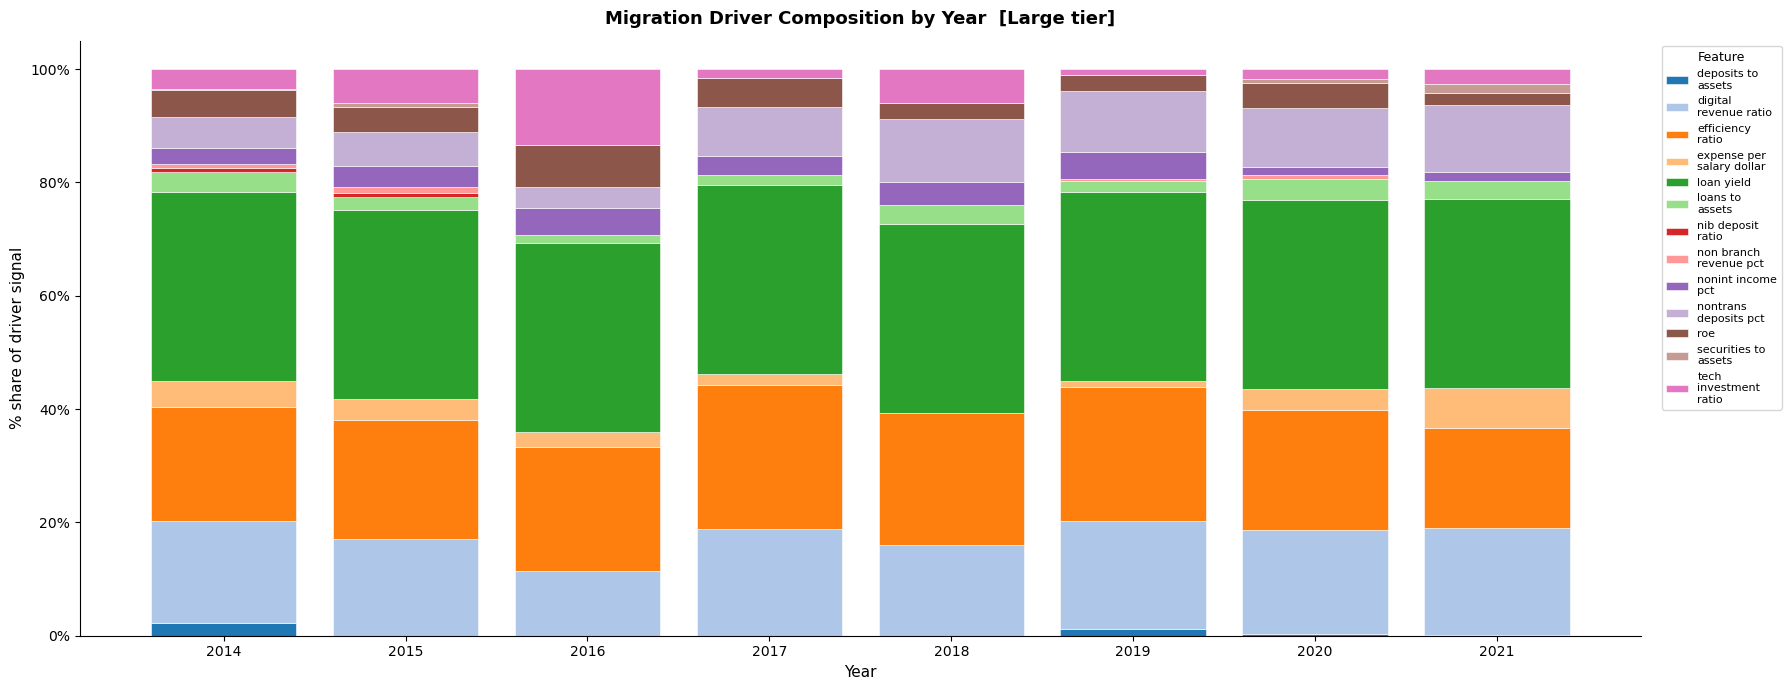

/Users/jacobstewart/Desktop/capstone/Captstone/bank_innovation/driver_analysis.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


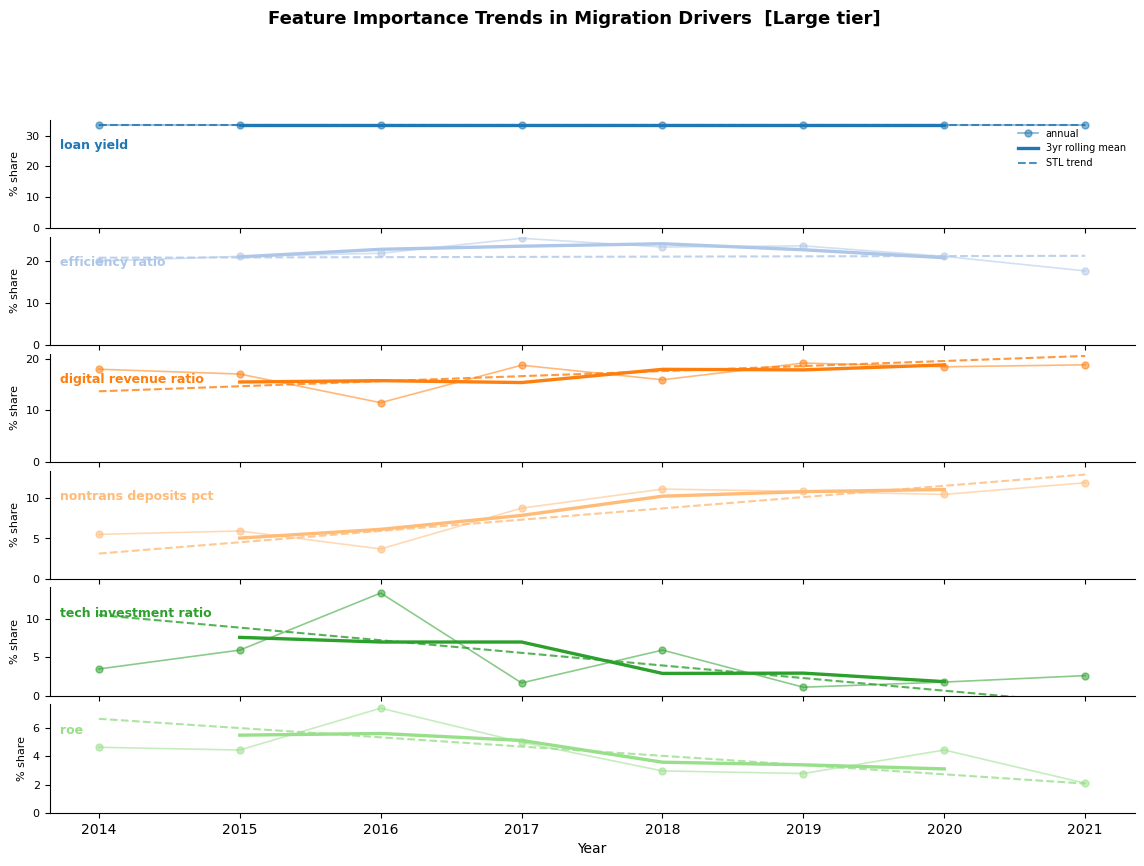

INFO:bank_innovation.driver_analysis:Driver frequency matrix [Medium]: 8 years × 13 features



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Large tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                                  mean_rank  rank_std  mean_pct_share  peak_year
loan_yield_change                      1.00      0.00           33.33       2014
efficiency_ratio_change                2.12      0.35           21.76       2017
digital_revenue_ratio_change           3.00      0.53           17.20       2019
nontrans_deposits_pct_change           4.44      1.05            8.52       2021
roe_change                             6.06      1.27            4.22       2016
tech_investment_ratio_change           6.56      2.15            4.48       2016
nonint_income_pct_change               7.25      1.73            3.31       2016
expense_per_salary_dollar_change       7.44      1.94            3.14       2021



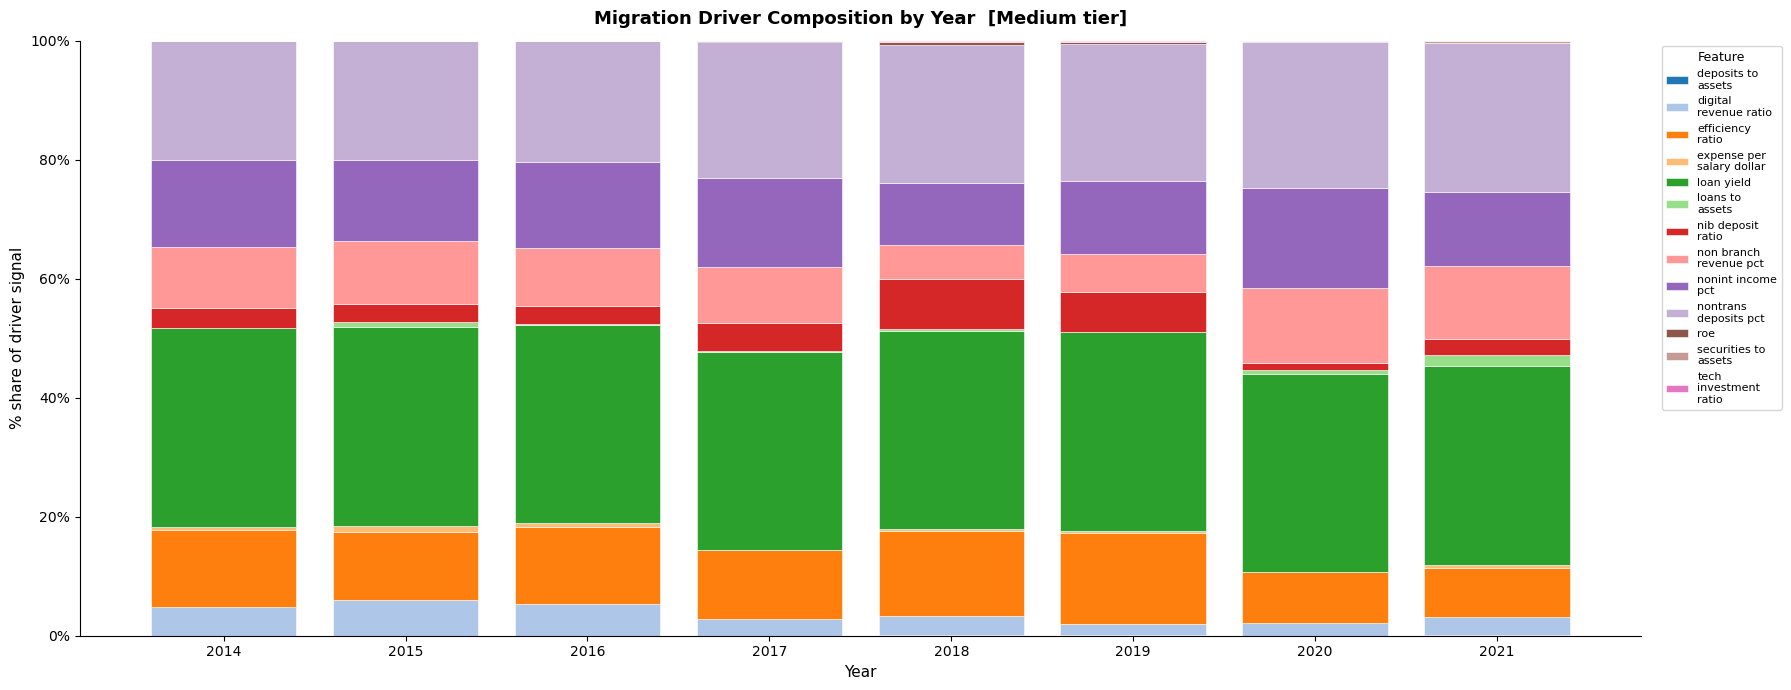

/Users/jacobstewart/Desktop/capstone/Captstone/bank_innovation/driver_analysis.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


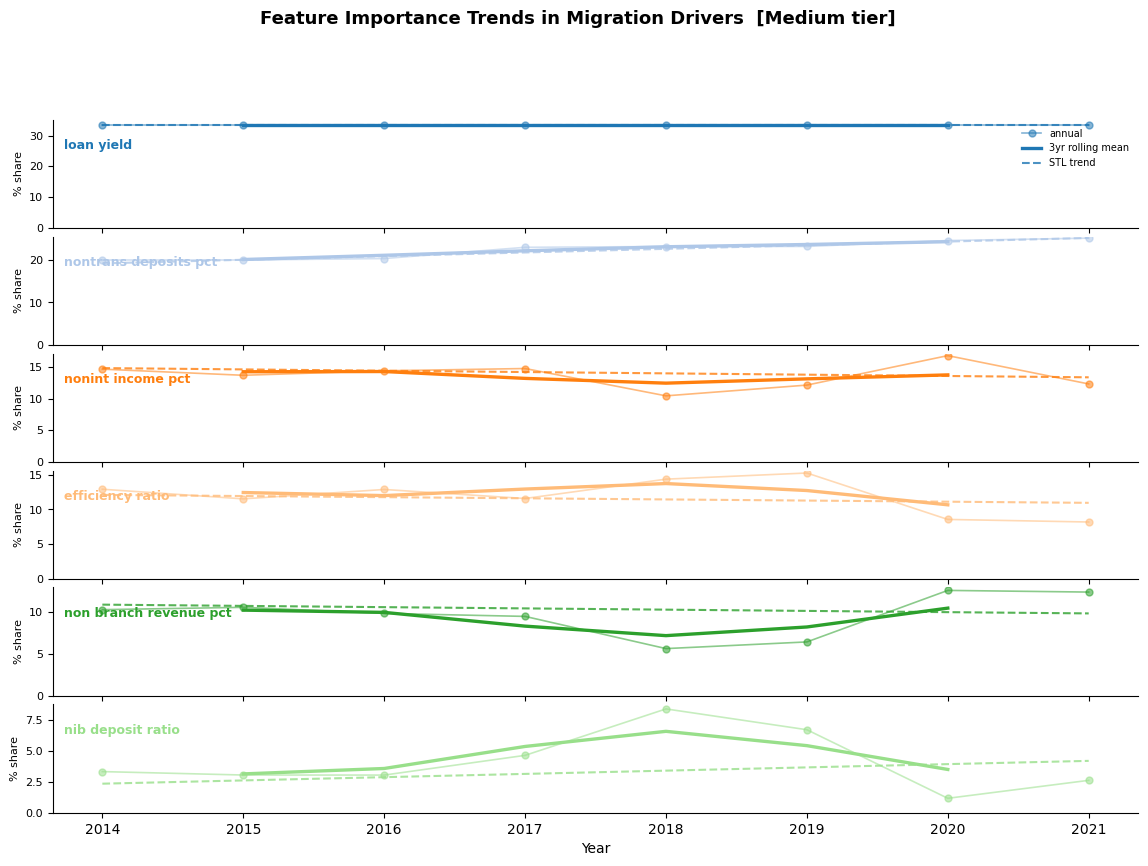

INFO:bank_innovation.driver_analysis:Driver frequency matrix [Small]: 8 years × 14 features



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Medium tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                                  mean_rank  rank_std  mean_pct_share  peak_year
loan_yield_change                      1.00      0.00           33.33       2014
nontrans_deposits_pct_change           2.00      0.00           22.42       2021
nonint_income_pct_change               3.31      0.46           13.71       2020
efficiency_ratio_change                4.00      0.76           11.91       2019
non_branch_revenue_pct_change          4.94      0.86            9.64       2020
digital_revenue_ratio_change           6.38      0.52            3.66       2015
nib_deposit_ratio_change               6.38      0.92            4.13       2018
expense_per_salary_dollar_change       9.31      1.67            0.43       2015



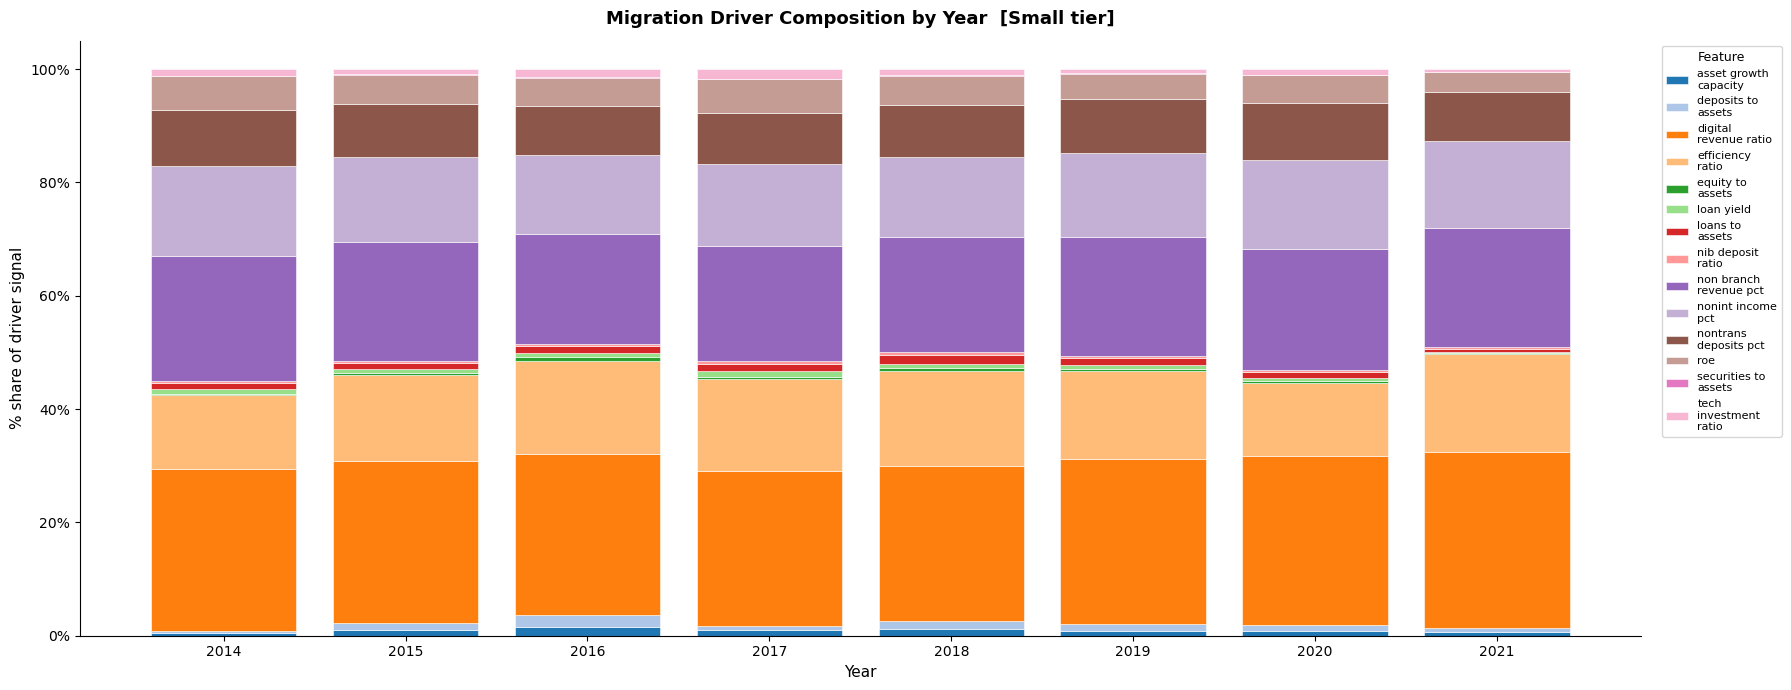

/Users/jacobstewart/Desktop/capstone/Captstone/bank_innovation/driver_analysis.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


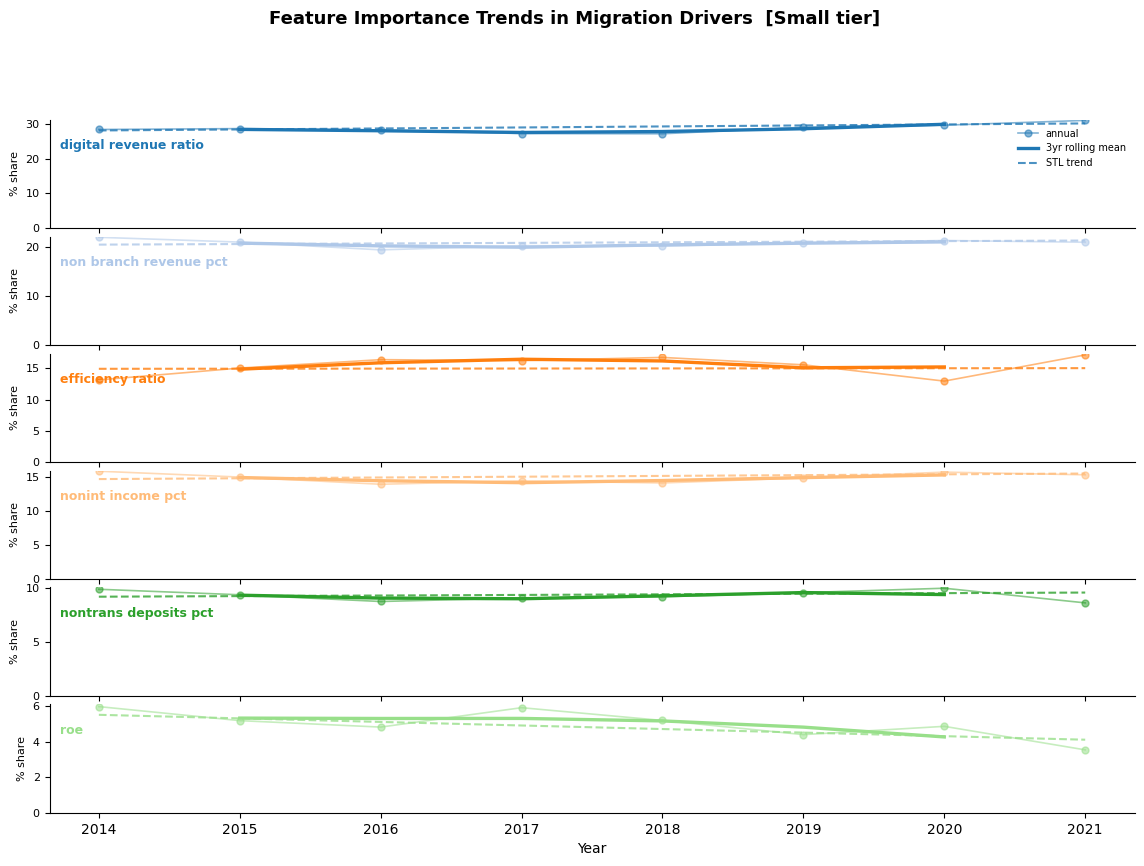

INFO:bank_innovation.driver_analysis:run_driver_analysis complete.



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Small tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                               mean_rank  rank_std  mean_pct_share  peak_year
digital_revenue_ratio_change        1.00      0.00           28.75       2021
non_branch_revenue_pct_change       2.00      0.00           20.76       2014
efficiency_ratio_change             3.25      0.46           15.42       2021
nonint_income_pct_change            3.75      0.46           14.92       2014
nontrans_deposits_pct_change        5.00      0.00            9.30       2020
roe_change                          6.00      0.00            5.00       2014
deposits_to_assets_change           8.12      1.55            1.12       2016
loans_to_assets_change              8.19      1.19            1.12       2018



In [15]:
results = run_driver_analysis(
    df_changes_optimized,
    migrations,                    # already computed in Cell 7
    tiers=["Large", "Medium", "Small"],
    top_n_drivers=5,
    rolling_window=3,
    save_dir="viz/driver_analysis",
)
 
# Everything is returned in the results dict:
driver_long    = results["driver_long"]    # raw long-form panel
pct_by_tier    = results["pct_by_tier"]    # {"Large": df, ...}
stability      = results["stability"]      # {"Large": df, ...}
figures        = results["figures"]        # list of matplotlib Figure objects
 

In [16]:
from bank_innovation.visualization import create_year_pair_plots

# All year pairs
saved = create_year_pair_plots(df_changes_optimized, output_dir='viz/')

# Or specific year pairs only
saved = create_year_pair_plots(
    df_changes_optimized,
    output_dir='viz/',
    year_pairs=[(2014, 2015), (2019, 2020)]
)

INFO:bank_innovation.visualization:Skipped 9 non-consecutive year pairs
INFO:bank_innovation.visualization:Creating per-year-pair visualizations for 0 year pairs
INFO:bank_innovation.visualization:All per-year-pair plots complete — 0 figures saved to viz/
INFO:bank_innovation.visualization:Creating per-year-pair visualizations for 2 year pairs
INFO:bank_innovation.visualization:All per-year-pair plots complete — 0 figures saved to viz/
